In [1]:
import mdtraj as md
import nglview as nv
import time

traj = md.load("mtd_fit.xtc", top="npt.pdb")

view = nv.show_mdtraj(traj)

view.clear_representations()

view.add_representation("cartoon", selection="protein", color="green")
view.add_representation("licorice", selection="protein", color="green")

view.center(selection="protein")
view


NGLWidget(max_frame=1000)

Salvato: rmsd.png


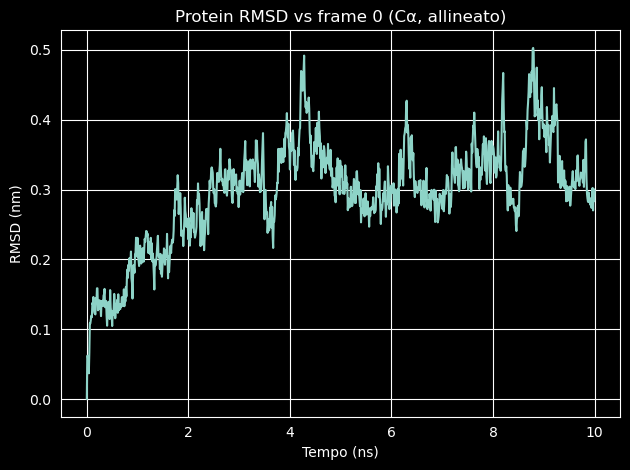

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md

traj = md.load("mtd_fit.xtc", top="npt.pdb")

# Selezione: C-alpha della proteina (fallback: backbone)
ca = traj.topology.select("protein and name CA")
if ca.size == 0:
    ca = traj.topology.select("protein and backbone")
if ca.size == 0:
    raise ValueError("Non trovo atomi 'protein' nella topologia (controlla npt.pdb).")

# RMSD vs frame 0 (aligned on CA/backbone)
rmsd_nm = md.rmsd(traj, traj, frame=0, atom_indices=ca)  # nm

# Asse x: tempo (ns) se disponibile, altrimenti frame
if getattr(traj, "time", None) is not None and len(traj.time) == traj.n_frames:
    t = traj.time.astype(float)
    # mdtraj spesso usa ps: se grande, converti a ns
    if np.nanmax(t) > 1e3:
        x = t / 1000.0
        xlabel = "Tempo (ns)"
    else:
        x = t
        xlabel = "Tempo"
else:
    x = np.arange(traj.n_frames)
    xlabel = "Frame"

plt.figure()
plt.plot(x, rmsd_nm)
plt.xlabel(xlabel)
plt.ylabel("RMSD (nm)")
plt.title("Protein RMSD vs frame 0 (Cα, allineato)")
plt.tight_layout()
plt.savefig("rmsd.png", dpi=200)
print("Salvato: rmsd.png")
